# =========================================
### Task 1: Problem Identification 
# =========================================

Problem Type: Image Classification

This dataset represents an image classification problem because:

Each image belongs to one predefined category.
The goal is to assign a single label to an image.
There are no bounding boxes or pixel-wise masks.
The model predicts one class among:
normal
scratch
dent
stain

Unlike object detection or segmentation, the task does not require locating defects inside the image.

Classes Found:
['dent', 'normal', 'scratch', 'stain']

Number of Classes: 4

Images Per Class:
     Class  Number of Images
0     dent               120
1   normal               120
2  scratch               120
3    stain               120


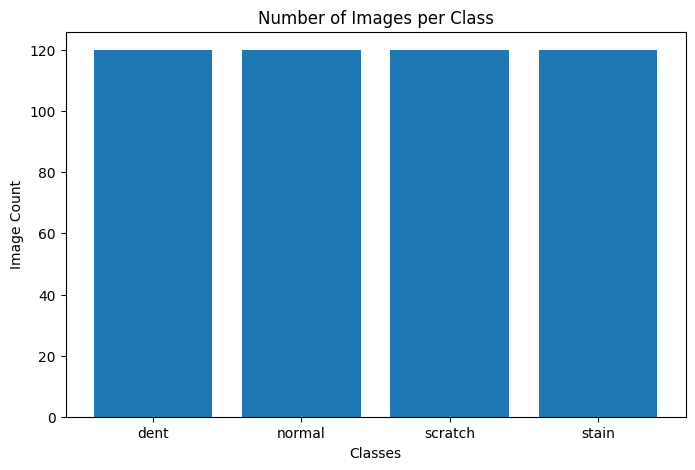


SAMPLE IMAGES FROM EACH CLASS:


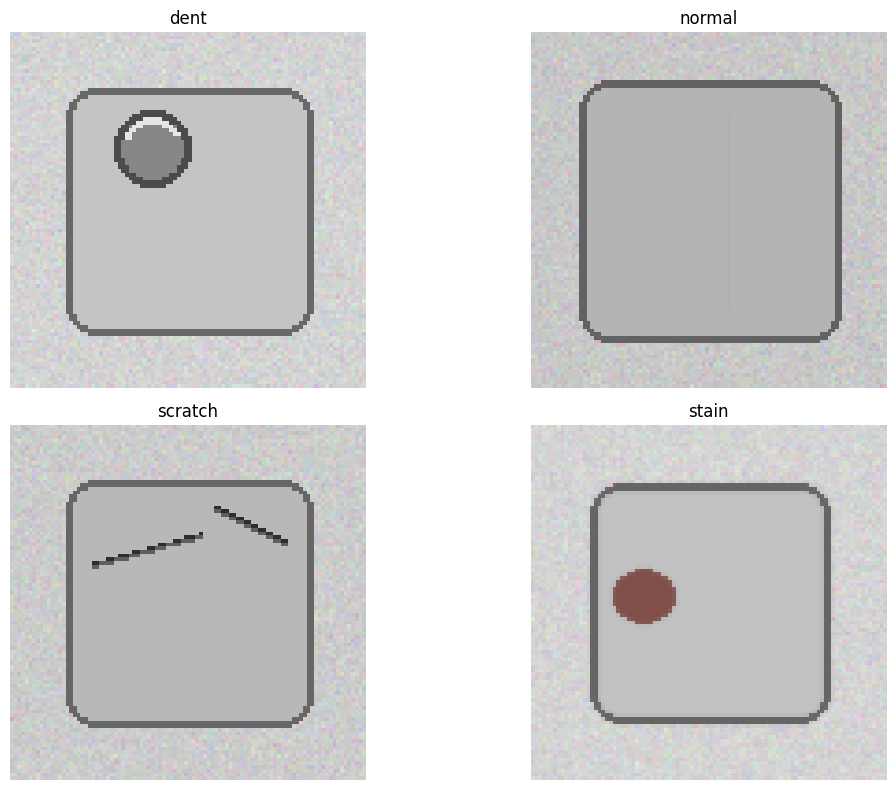


Image Dimensions:
dent: 96 x 96
normal: 96 x 96
scratch: 96 x 96
stain: 96 x 96

Dataset Imbalance Analysis:
Dataset is fairly balanced.

Observations:
1. Total Classes: 4
2. Image count per class displayed above.
3. Sample images from each class displayed.
4. Image dimensions displayed above.
5. Dataset is balanced.


In [25]:
# =========================================
### Task 2: Problem Identification 
# =========================================

import os
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image

# =========================================
# DATASET PATH
# =========================================

dataset_path = "images"

# =========================================
# GET CLASS NAMES
# =========================================

classes = [
    cls for cls in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, cls))
]

print("Classes Found:")
print(classes)

# =========================================
# NUMBER OF CLASSES
# =========================================

num_classes = len(classes)

print("\nNumber of Classes:", num_classes)

# =========================================
# NUMBER OF IMAGES PER CLASS
# =========================================

image_count = {}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = os.listdir(class_path)

    image_count[cls] = len(images)

# Create DataFrame
df = pd.DataFrame(
    image_count.items(),
    columns=["Class", "Number of Images"]
)

print("\nImages Per Class:")
print(df)

# =========================================
# BAR PLOT FOR CLASS DISTRIBUTION
# =========================================

plt.figure(figsize=(8,5))

plt.bar(df["Class"], df["Number of Images"])

plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Image Count")

plt.show()

# =========================================
# SAMPLE IMAGES FROM EACH CLASS
# =========================================

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    # Open image using PIL
    img = Image.open(img_path)

    plt.subplot(2, 2, i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
print("\nSAMPLE IMAGES FROM EACH CLASS:")
plt.show()

# =========================================
# IMAGE DIMENSIONS
# =========================================

print("\nImage Dimensions:")

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    width, height = img.size

    print(f"{cls}: {width} x {height}")

# =========================================
# CHECK DATASET IMBALANCE
# =========================================

max_images = max(image_count.values())
min_images = min(image_count.values())

print("\nDataset Imbalance Analysis:")

if max_images - min_images > 50:
    print("Dataset is imbalanced.")
else:
    print("Dataset is fairly balanced.")

# =========================================
# OBSERVATIONS
# =========================================

print("\nObservations:")

print(f"1. Total Classes: {num_classes}")

print("2. Image count per class displayed above.")

print("3. Sample images from each class displayed.")

print("4. Image dimensions displayed above.")

if max_images - min_images > 50:
    print("5. There is imbalance in dataset.")
else:
    print("5. Dataset is balanced.")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


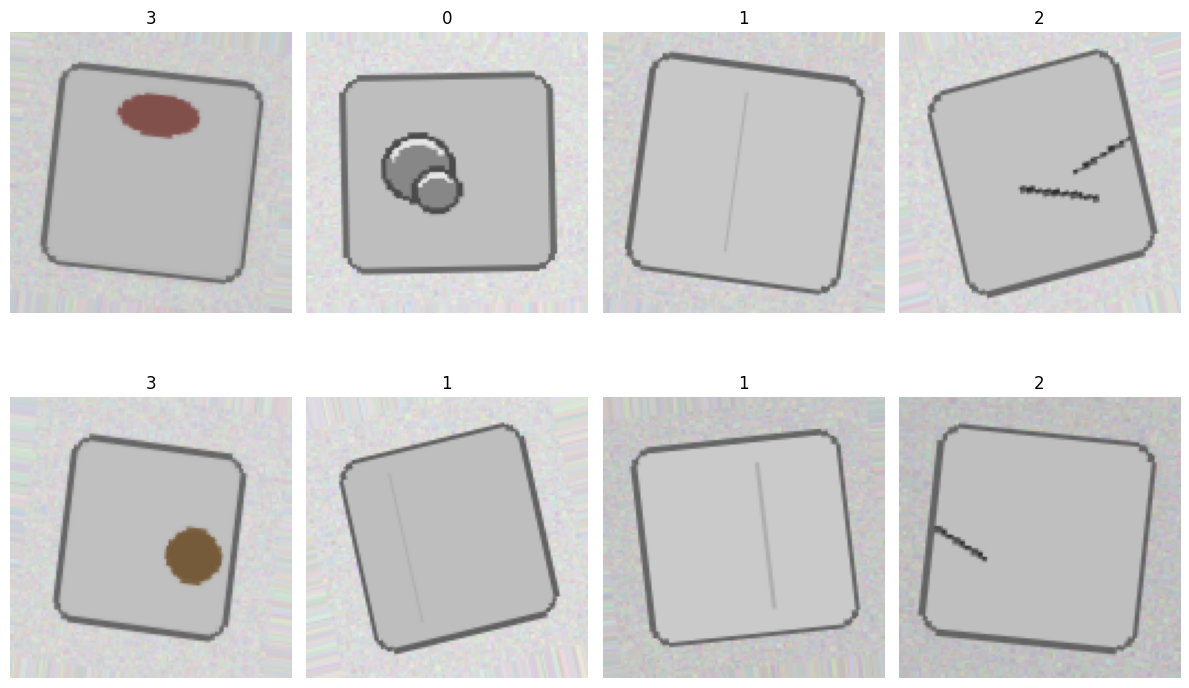


Image Preprocessing Completed

Image Size:
128 x 128

Batch Size:
32

Training Samples:
384

Testing Samples:
96

Class Names:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}


In [26]:
# =========================================
### Task 3: Image Preprocessing
# =========================================

import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================================
# DATASET PATH
# =========================================

dataset_path = "images"

# =========================================
# IMAGE SETTINGS
# =========================================

img_height = 128
img_width = 128
batch_size = 32

# =========================================
# IMAGE DATA GENERATOR
# =========================================
# Rescaling = Normalization
# validation_split = Train/Test Split
# rotation/zoom/flip = Data Augmentation

datagen = ImageDataGenerator(
    
    rescale=1./255,
    
    validation_split=0.2,
    
    rotation_range=15,
    
    zoom_range=0.1,
    
    horizontal_flip=True
)

# =========================================
# TRAINING DATA
# =========================================

train_generator = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(img_height, img_width),
    
    batch_size=batch_size,
    
    class_mode='categorical',
    
    subset='training',
    
    shuffle=True
)

# =========================================
# TESTING / VALIDATION DATA
# =========================================

test_generator = datagen.flow_from_directory(
    
    dataset_path,
    
    target_size=(img_height, img_width),
    
    batch_size=batch_size,
    
    class_mode='categorical',
    
    subset='validation',
    
    shuffle=False
)

# =========================================
# DISPLAY PREPROCESSED IMAGES
# =========================================

import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(8):
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(images[i])
    
    plt.title(np.argmax(labels[i]))
    
    plt.axis("off")

plt.tight_layout()

plt.show()

# =========================================
# PRINT DATA INFORMATION
# =========================================

print("\nImage Preprocessing Completed")

print("\nImage Size:")
print(f"{img_height} x {img_width}")

print("\nBatch Size:")
print(batch_size)

print("\nTraining Samples:")
print(train_generator.samples)

print("\nTesting Samples:")
print(test_generator.samples)

print("\nClass Names:")
print(train_generator.class_indices)

# Task 3: Image Preprocessing

## Image Preprocessing Summary

The image dataset was preprocessed before training the CNN model.

---

## Preprocessing Steps Performed

### 1. Image Resizing

- All images were resized to **128 × 128 pixels**.
- Resizing ensures that all images have a consistent size before being fed into the CNN model.
- This also helps reduce computational complexity and training time.

---

### 2. Normalization

- Pixel values were normalized using the following formula:

\[
x_{normalized} = \frac{x}{255}
\]

- Normalization converts pixel values from the range **0–255** to **0–1**.
- This improves model performance and speeds up convergence during training.

---

### 3. Train-Test Split

- The dataset was divided into:
  - **80% Training Data**
  - **20% Testing/Validation Data**

- The split was performed using the `validation_split` parameter in `ImageDataGenerator`.

---

### 4. Data Augmentation

To improve model generalization and reduce overfitting, data augmentation techniques were applied:

- Rotation
- Zooming
- Horizontal Flipping

These transformations generate modified versions of images during training, helping the CNN learn better features.

---

### 5. Batch Processing

- Images were loaded in batches of **32**.
- Batch processing improves memory efficiency and speeds up training.

---

## Conclusion

The dataset was successfully preprocessed by resizing images, normalizing pixel values, splitting data into training and testing sets, and applying augmentation techniques. These preprocessing steps prepare the dataset effectively for CNN model training.

In [27]:
# =========================================
# TASK 4: CNN MODEL CREATION
# =========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# =========================================
# NUMBER OF CLASSES
# =========================================

num_classes = len(train_generator.class_indices)

# =========================================
# CREATE CNN MODEL
# =========================================

model = Sequential()

# =========================================
# 1st CONVOLUTION LAYER
# =========================================

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# =========================================
# POOLING LAYER
# =========================================

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# =========================================
# 2nd CONVOLUTION LAYER
# =========================================

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

# =========================================
# POOLING LAYER
# =========================================

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# =========================================
# 3rd CONVOLUTION LAYER
# =========================================

model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    )
)

# =========================================
# POOLING LAYER
# =========================================

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# =========================================
# FLATTEN LAYER
# =========================================

model.add(Flatten())

# =========================================
# DENSE LAYER
# =========================================

model.add(Dense(128, activation='relu'))

# DROPOUT FOR OVERFITTING REDUCTION
model.add(Dropout(0.5))

# =========================================
# OUTPUT LAYER
# =========================================

model.add(
    Dense(
        num_classes,
        activation='softmax'
    )
)

# =========================================
# DISPLAY MODEL SUMMARY
# =========================================

model.summary()

C:\Users\plsha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: CNN Model Creation

## CNN Model Summary

A Convolutional Neural Network (CNN) model was created using TensorFlow/Keras for image classification.

The CNN model consists of multiple layers that help extract features from images and classify them into different categories.

---

# Layers Used in the CNN Model

## 1. Convolution Layer

- Convolution layers are used to extract important features from images such as edges, textures, and shapes.
- The model contains three convolution layers:
  - 32 filters
  - 64 filters
  - 128 filters
- Kernel size used: `3 × 3`

### Activation Function Used

- The **ReLU (Rectified Linear Unit)** activation function was used.

:contentReference[oaicite:0]{index=0}

- ReLU helps introduce non-linearity into the model and improves training performance.

---

## 2. Pooling Layer

- Max Pooling layers were added after each convolution layer.
- Pool size used: `2 × 2`

- Pooling reduces image dimensions and computational complexity while preserving important features.

---

## 3. Flatten Layer

- The Flatten layer converts the 2D feature maps into a 1D vector.
- This allows the data to be passed into fully connected dense layers.

---

## 4. Dense Layer

- A Dense (fully connected) layer with 128 neurons was added.
- ReLU activation function was used in this layer.

- A Dropout layer with `0.5` dropout rate was also added to reduce overfitting.

---

## 5. Output Layer

- The output layer contains neurons equal to the number of image classes.
- The **Softmax** activation function was used for multi-class classification.

:contentReference[oaicite:1]{index=1}

- Softmax converts outputs into probability values between 0 and 1.

---

# Conclusion

The CNN architecture was successfully created using convolution, activation, pooling, flatten, dense, and output layers. The model is suitable for image classification tasks and capable of learning important visual patterns from the dataset.

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 506ms/step - accuracy: 0.6510 - loss: 1.0762 - val_accuracy: 0.7292 - val_loss: 0.6012
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.7318 - loss: 0.6711 - val_accuracy: 0.8542 - val_loss: 0.4639
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 425ms/step - accuracy: 0.8073 - loss: 0.5254 - val_accuracy: 0.8542 - val_loss: 0.3734
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 424ms/step - accuracy: 0.8203 - loss: 0.4692 - val_accuracy: 0.9167 - val_loss: 0.2922
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step - accuracy: 0.8411 - loss: 0.4248 - val_accuracy: 0.9271 - val_loss: 0.2697
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.8698 - loss: 0.3559 - val_accuracy: 0.9167 - val_loss: 0.2697
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 414ms/step - accuracy: 0.8464 - loss: 0.3976 - val_accuracy: 0.9375 - val_loss: 0.2531
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.8698 - loss: 0.3444 - val_accuracy: 0.

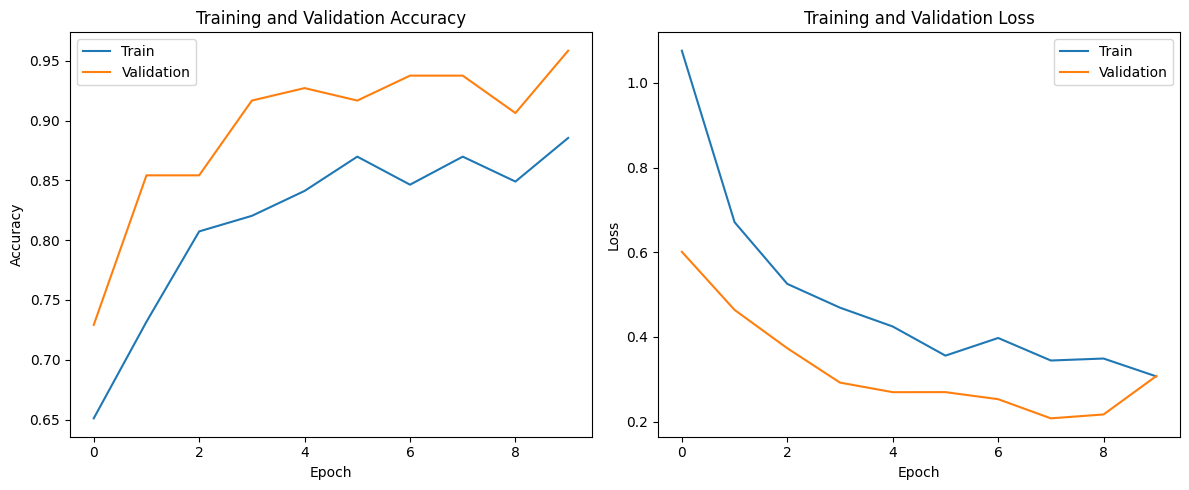

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9583 - loss: 0.3068

TESTING PERFORMANCE

Test Loss: 0.3068
Test Accuracy: 0.9583
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step


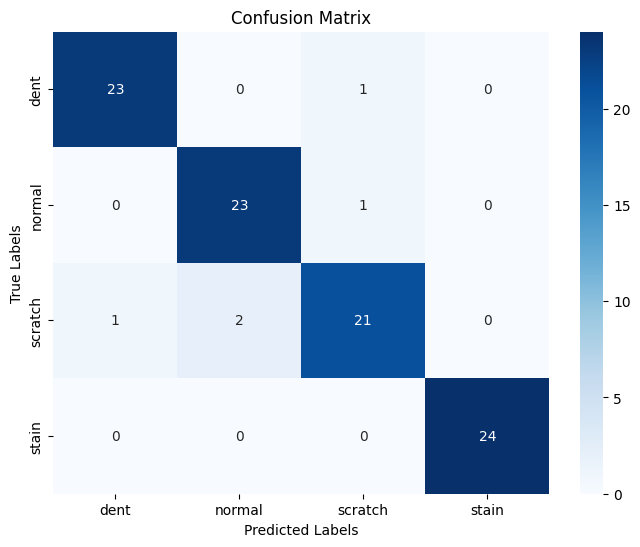


CLASSIFICATION REPORT

              precision    recall  f1-score   support

        dent       0.96      0.96      0.96        24
      normal       0.92      0.96      0.94        24
     scratch       0.91      0.88      0.89        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.95        96
   macro avg       0.95      0.95      0.95        96
weighted avg       0.95      0.95      0.95        96

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


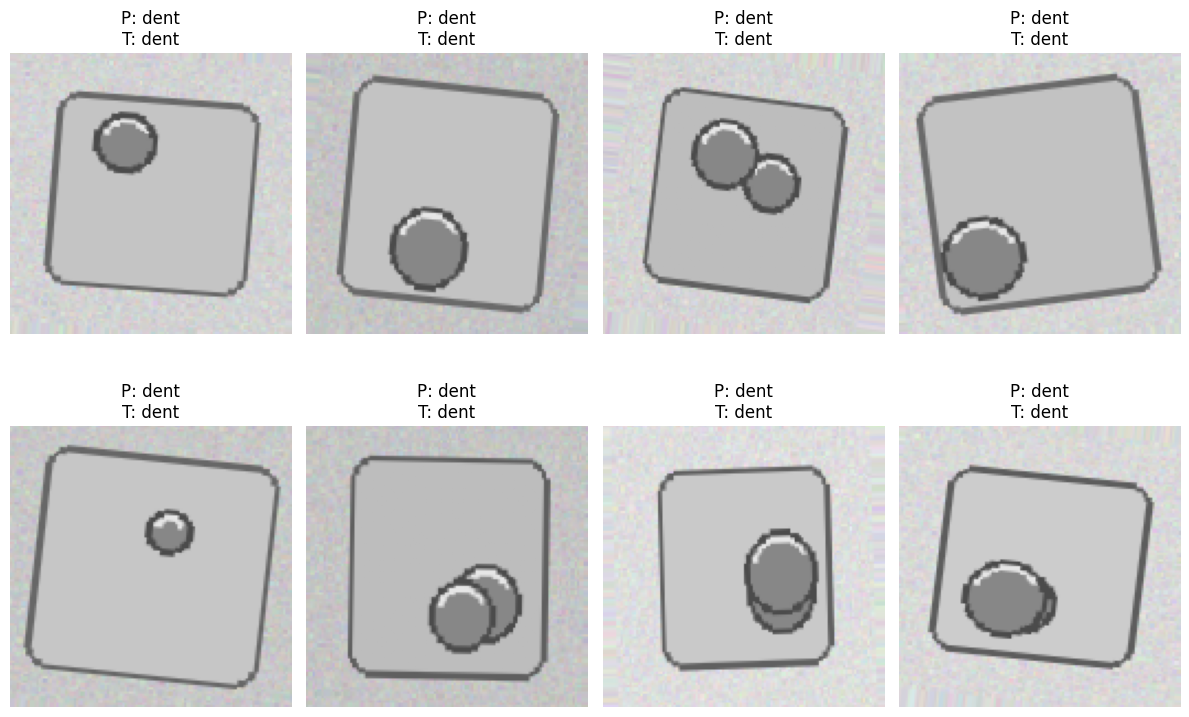

In [29]:
# =========================================
# TASK 5: MODEL TRAINING AND EVALUATION
# =========================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.optimizers import Adam

# =========================================
# CREATE RESULTS FOLDER
# =========================================

os.makedirs("results", exist_ok=True)

# =========================================
# COMPILE MODEL
# =========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================
# TRAIN MODEL
# =========================================

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

# =========================================
# TRAINING ACCURACY & LOSS
# =========================================

print("\n===================================")
print("TRAINING ACCURACY AND LOSS")
print("===================================")

print("\nTraining Accuracy Per Epoch:")
print(history.history['accuracy'])

print("\nTraining Loss Per Epoch:")
print(history.history['loss'])

# =========================================
# VALIDATION ACCURACY & LOSS
# =========================================

print("\n===================================")
print("VALIDATION ACCURACY AND LOSS")
print("===================================")

print("\nValidation Accuracy Per Epoch:")
print(history.history['val_accuracy'])

print("\nValidation Loss Per Epoch:")
print(history.history['val_loss'])

# =========================================
# FINAL TRAINING RESULTS
# =========================================

final_train_accuracy = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

final_val_accuracy = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"\nFinal Training Accuracy: {final_train_accuracy:.4f}")

print(f"Final Training Loss: {final_train_loss:.4f}")

print(f"\nFinal Validation Accuracy: {final_val_accuracy:.4f}")

print(f"Final Validation Loss: {final_val_loss:.4f}")

# =========================================
# PLOT ACCURACY & LOSS GRAPHS
# =========================================

plt.figure(figsize=(12,5))

# -----------------------------------------
# ACCURACY GRAPH
# -----------------------------------------

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

# -----------------------------------------
# LOSS GRAPH
# -----------------------------------------

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.tight_layout()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

# =========================================
# TESTING PERFORMANCE
# =========================================

test_loss, test_accuracy = model.evaluate(test_generator)

print("\n===================================")
print("TESTING PERFORMANCE")
print("===================================")

print(f"\nTest Loss: {test_loss:.4f}")

print(f"Test Accuracy: {test_accuracy:.4f}")

# =========================================
# PREDICTIONS
# =========================================

test_generator.reset()

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")

plt.show()

# =========================================
# CLASSIFICATION REPORT
# =========================================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# =========================================
# SAMPLE PREDICTIONS
# =========================================

sample_images, sample_labels = next(test_generator)

sample_predictions = model.predict(sample_images)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(sample_images[i])

    predicted_class = class_names[
        np.argmax(sample_predictions[i])
    ]

    true_class = class_names[
        np.argmax(sample_labels[i])
    ]

    plt.title(
        f"P: {predicted_class}\nT: {true_class}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Task 7: Business Use Case Mapping

## Computer Vision in Healthcare

Computer vision solutions using CNN models can be widely used in the healthcare industry for medical image analysis and disease detection.

### Example Use Case: Disease Detection from Medical Images

CNN-based image classification systems can analyze medical images such as:
- X-rays
- MRI scans
- CT scans
- Skin disease images

The model can automatically identify diseases or abnormalities from these images.

---

## How It Works

1. Medical images are collected from patients.
2. Images are preprocessed and fed into the CNN model.
3. The CNN extracts important visual features from the image.
4. The model predicts whether the image indicates a disease or a healthy condition.

---

## Benefits of Computer Vision in Healthcare

### 1. Faster Diagnosis
- CNN models can analyze images quickly.
- Doctors receive faster diagnostic support.

### 2. Improved Accuracy
- Deep learning models can detect patterns that may be difficult for humans to notice.

### 3. Reduced Human Error
- Automated systems help reduce misdiagnosis.

### 4. Cost and Time Efficiency
- Automated screening reduces workload for healthcare professionals.

### 5. Early Disease Detection
- Diseases can be identified at an early stage, improving treatment outcomes.

---

## Real-World Applications

Computer vision in healthcare is used for:
- Tumor detection
- Pneumonia detection from chest X-rays
- Skin cancer classification
- Diabetic retinopathy detection
- Brain scan analysis

---

# Conclusion

CNN-based computer vision systems provide powerful solutions for healthcare image analysis. They improve diagnostic accuracy, speed, and efficiency, making healthcare services more reliable and accessible.